# CODIS: Analyzing STR Profiles and DNA Forensics
### Data Science for Biology

**Notebook developed by:** *Shishi Luo, Sarp Dora Kurtoglu, Kinsey Long*<br>
**Supervised by:** *Steven Brenner*<br>

### Learning Outcomes

In this notebook, you will learn about and practice:
* Intermediate Pandas methods
* Seaborn histograms
* Probability
* Nested for loops
* STRs used for forensics in CODIS

---
#### **Exporting Chats**

When AI tools are used to assist in solving a problem, we will ask for transcripts of any chat sessions as a PDF. Unfortunately, getting Gemini to print a PDF of a chat session while using a CalNet account is not a trivial operation. Here is our suggested solution:

1. Click the `Tools` button at the bottom of the chat box.
2. Select `Canvas`.
3. Copy and paste the following into Gemini:

> Please transcribe our entire conversation word-for-word into a new Canvas document

4. Print to PDF

Alternatively, there are browser-specific extensions that enable chat export. If you choose to use one of these options ***be sure that the extension is one which runs locally, not uploading any data to the cloud***.

#### Use of AI

Throughout this and future labs, we will be explicit about where use of AI is permitted. There will be three possible options, which will be stated up front for each question:

* <font color = #0fd12c>**AI PERMITTED**</font>
* <font color = #d1b70f>**AI REQUIRED**</font>
* <font color = #d14d0f>**NO AI**</font>

#### Submission requirements:

The following are what you are expected to submit:

* Copy of the `.ipynb` notebook file
* PDF version of the notebook file
    * On the DataHub, choose `Export as WebPDF`
* PDF export of Gemini chat logs (if Gemini was used)

---
### Helpful Data Science Resources
Here are some resources you can check out while doing this notebook:

- [Introductory documentation for pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- [Conditional Probability with Khan Academy](https://www.khanacademy.org/math/ap-statistics/probability-ap/stats-conditional-probability/v/bayes-theorem-visualized)

### Peer Consulting

If you find yourself having trouble with any content in this notebook, Data Peer Consultants are an excellent resource. Click [here](https://dlab.berkeley.edu/training/frontdesk-info) to locate live help.

Peer Consultants are there to answer all data-related questions, whether it be about the content of this notebook, applications of data science in the world, or other data science courses offered at Berkeley.

---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

sns.set_theme()

print("All necessary packages have been imported!")

All necessary packages have been imported!


## Background
FBI uses a system called CODIS (Combined DNA Index System) to help support and solve criminal cases. The DNA Profile of a suspect is compared against large DNA databases to look for a match. These profiles are determined by DNA short tandem repeat (STR) Analysis with information about allele(s) at the 20 CODIS Core Loci. 

The FBI FAQ about these is [here.](https://www.fbi.gov/resources/dna-fingerprint-act-of-2005-expungement-policy/codis-and-ndis-fact-sheet)<br>
A description of how these are used is [here.](https://www.nature.com/scitable/topicpage/forensics-dna-fingerprinting-and-codis-736)

Until December 31, 2016, there were 13 CODIS Core Loci:

> CSF1PO, FGA, TH01, TPOX, vWA, D3S1358, D5S818, D7S820, D8S1179, D13S317, D16S539, D18S51, D21S11

Later on, 7 more were added, to create a set of 20 CODIS Core Loci:

> CSF1PO, FGA, TH01, TPOX, vWA, D3S1358, D5S818, D7S820, D8S1179, D13S317, D16S539, D18S51, D21S11, D1S1656, D2S441, D2S1338, D10S1248, D12S391, D19S433, D22S1045

In this assignment, we will be using a small set of CODIS data.


## Import the Data

Let's read the raw data in comma separated values format, collected by NIST (National Institute of Standards and Technology) which you can find in the `Data` folder under the name `CODIS_profiles.csv`.  

In [2]:
#Just run this cell
raw_profiles = pd.read_csv("data/CODIS_profiles.csv")
raw_profiles.head()

,Group,SampleCode,AMEL,AMEL.1,CSF1PO,CSF1PO.1,D10S1248,D10S1248.1,D12S391,D12S391.1,...,DYS456,DYS458,DYS481,DYS533,DYS549,DYS570,DYS576,DYS635,DYS643,Y-GATA-H4
0,Cauc,BC11352,X,Y,11,13,13,15,17.0,18.0,...,15,18,23,12,13,16,19,20,9,12
1,Hisp,GA05070,X,Y,10,12,12,14,17.3,23.0,...,17,15,25,11,12,16,17,22,11,12
2,Hisp,GA05071,X,Y,11,15,14,16,19.0,20.0,...,15,16,22,12,13,18,18,23,10,12
3,Cauc,GC03394,X,Y,10,12,15,16,19.0,19.0,...,13,16,22,12,13,18,16,21,9,11
4,Cauc,GT36864,X,Y,10,12,15,17,17.3,20.0,...,14,15,24,11,13,20,16,21,12,11


This is an example DNA database used by the FBI. The first row contains headings, including the names of all 20 CODIS Core Loci. Each row after the first one corresponds to an individual and their unique counts for each of the CODIS Core Loci. The alleles here refer to the number of STR repeats in each CODIS Core Loci. Most loci are named as XXXX and XXXX.1. These represent the same locus on the homologous chromosomes. Considering both represents diploid characteristics. For example, the first individual in the dataset has 11 for CSF1PO and 13 for CSF1PO.1. This means that on one chromosome they have 11 repeats at the CSF1PO locus, while on the other chromosome they have 13 repeats at the CSF1PO locus.  Each allele at a locus is named by the number of short tandem repeats; e.g., 6 repeats would be called "allele 6."  (This might seem obvious, but often alleles are named in different ways.) By convention, the smaller number of STR counts is in the XXXX column, and the larger number of STR counts is in the XXXX.1 column.

## Restricting to CODIS original core loci
For this part of the project, we're just going to use the original 13 CODIS loci: TPOX, D3S1358, FGA, D5S818, CSF1PO, D7S820, D8S1179, TH01, VWA, D13S317, D16S539, D18S51, D21S11.

To keep things simple for this part of the lab, we will be considering only one allele from each person, by ignoring the columns with name of the form XXXX.1. We'll also ignore the first two columns which contain ethnic information and the unique identifier.

<font color = #d14d0f>**QUESTION 1**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a new DataFrame `CODIS_profiles` which contains data for only the 13 CODIS core loci of each individual. Use the list `CODIS_13_loci`, which contains all 13 STR loci used for DNA fingerprinting as described below, in your code for creating the table. 

In [3]:
# Question 1

CODIS_13_loci = ['TPOX', 'D3S1358', 'FGA', 'D5S818', 
            'CSF1PO', 'D7S820', 'D8S1179', 'TH01', 'vWA',
            'D13S317', 'D16S539', 'D18S51', 'D21S11']

# YOUR CODE HERE
CODIS_profiles = raw_profiles[CODIS_13_loci]

# DO NOT CHANGE CODE BELOW
CODIS_profiles.head()

,TPOX,D3S1358,FGA,D5S818,CSF1PO,D7S820,D8S1179,TH01,vWA,D13S317,D16S539,D18S51,D21S11
0,8,14.0,24.0,10,11,10.0,13,6.0,17,13,8,13.0,28.0
1,8,16.0,25.0,11,10,10.0,10,7.0,14,10,10,16.0,30.0
2,8,14.0,23.0,11,11,7.0,13,7.0,16,11,12,17.0,30.2
3,8,15.0,21.0,11,10,11.0,12,6.0,17,11,12,15.0,30.0
4,9,15.0,19.0,9,10,8.0,13,7.0,16,11,11,14.0,31.2


## Exploration and Visualization
The following code plots the distribution of the STR counts for the locus 'TPOX' using the `seaborn` package, abbreviated as `sns`. A histogram can be generated using the figure-level function `sns.displot(data)` (often easier to use for quick plots), or the axes-level function `sns.histplot(data)` (more flexible; more like matplotlib).

You can read the documentation for `sns.displot(data)` [here](https://seaborn.pydata.org/generated/seaborn.displot.html), or for `sns.histplot(data)` [here](https://seaborn.pydata.org/generated/seaborn.histplot.html).


In Data 8, we plotted a histogram using `Table.hist(column_label)`. The primary difference for seaborn is the way the dataframe is input as a parameter, instead of the visualization method being called on the Table object.

An important note is that STR count is a discrete variable, not continuous. Therefore, it is important that we include the `discrete = True` parameter, which centers our x-axis values under the bar.

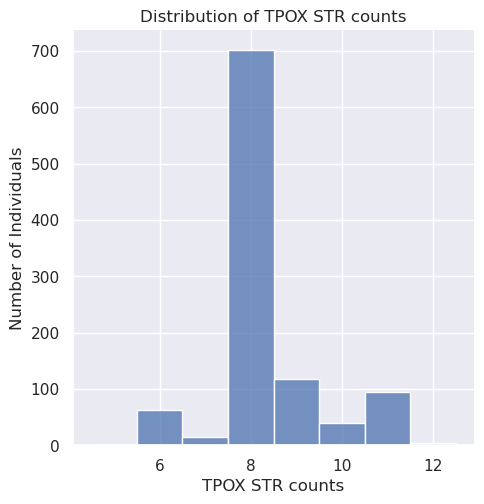

In [4]:
#Just run this cell
sns.displot(CODIS_profiles, x = "TPOX", discrete=True)
plt.title("Distribution of TPOX STR counts")
plt.xlabel("TPOX STR counts")
plt.ylabel("Number of Individuals")
plt.show()

You'll see that the values (the alleles in this case) range from 6 to 11 with a peak at 8. This means that within the population in our DNA dataset, having 8 counts at the TPOX CODIS Core locus is the most common case.

<font color = #d14d0f>**QUESTION 2**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Fill in the code below to create separate bar charts for each CODIS locus (including TPOX), to get a sense of the allelic variation and how concentrated the distributions might be.

Additionally, make sure the plot is legible and interpretable, including the following:

* Make sure each bar chart has appropriate title and axis labels
* Make sure the titles and labels are large enough to be legible
* Tweak the layout so that the subplots fit comfortably on the screen

>**Hint**: Currently, the DataFrame is more wide-form than long-form. How might you reshape the data to be in a form that seaborn prefers? See https://seaborn.pydata.org/tutorial/data_structure.html for guidance.

>**Hint**: [`sns.displot`](https://seaborn.pydata.org/generated/seaborn.displot.html) can perform faceting automatically, and allows you to tweak the layout. Some layout settings are provided in the example code below. Also see the examples in this documentation of how to set titles and labels when faceting.

>**Hint**: Alternatively, you can use [`sns.FacetGrid`](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) to create subplots and then manually map `sns.histplot` onto that grid. This may afford you more flexibility for fine-tuning how the plots look, at the cost of familarizing yourself with the inner workings of seaborn.


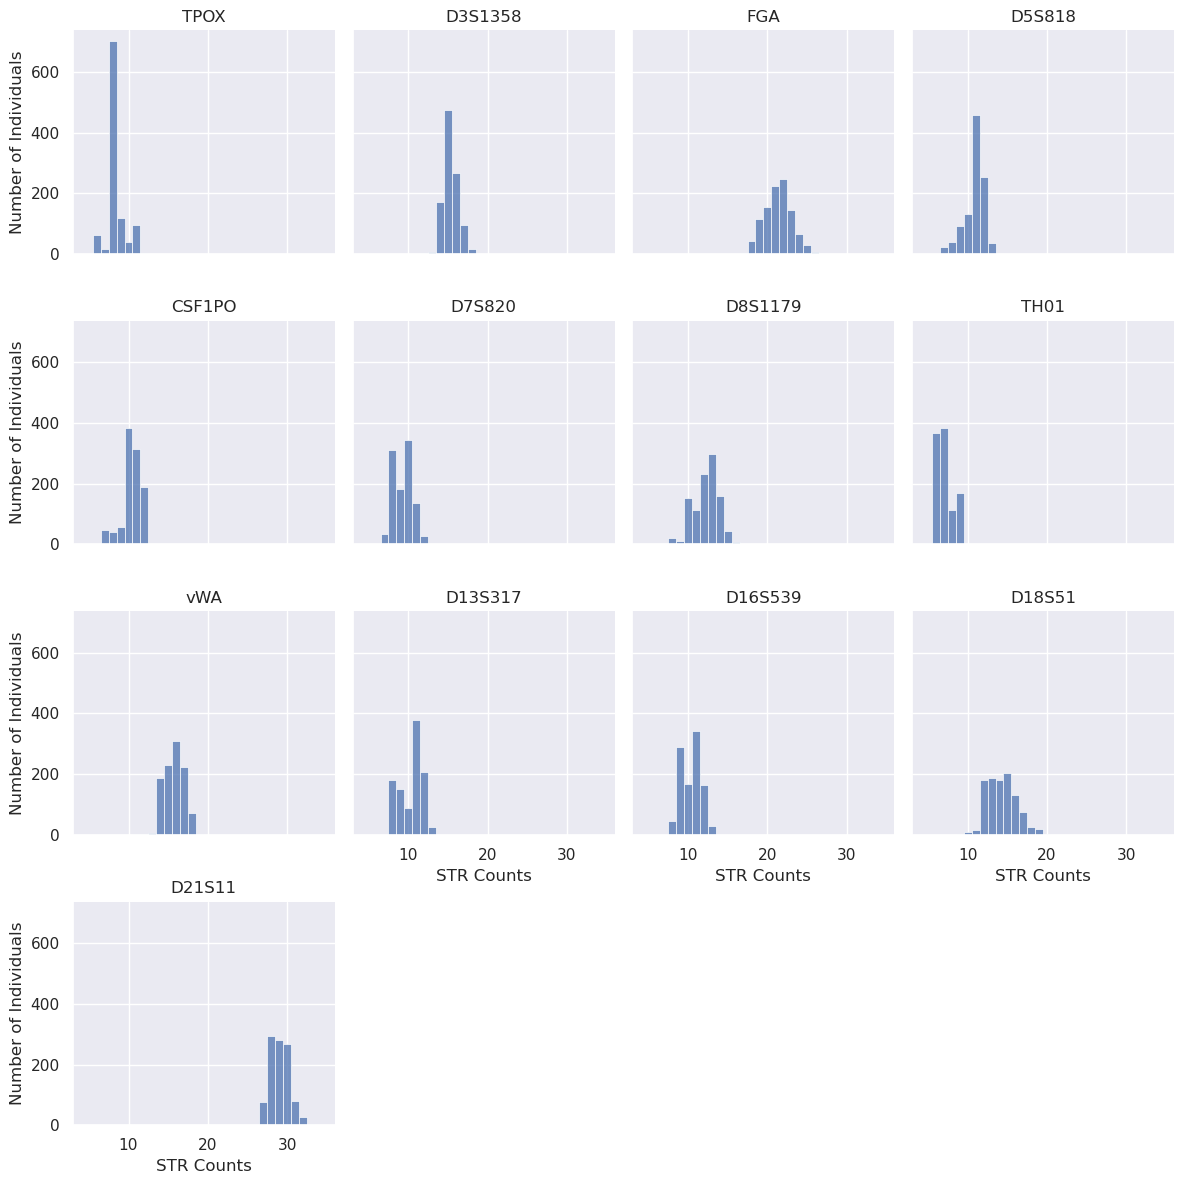

In [5]:
# Question 2

# YOUR CODE HERE
CODIS_long = CODIS_profiles.melt(var_name="Locus", value_name="STR Count")

# Create faceted plots for each locus
g = sns.displot(
    data=CODIS_long, 
    x="STR Count",
    col="Locus", 
    col_wrap=4, 
    discrete=True, 
    height=3
)

# Set descriptive titles and labels for the facets
g.set_titles("{col_name}")
g.set_axis_labels("STR Counts", "Number of Individuals")

# Tweak the layout for better legibility
plt.tight_layout()
# DO NOT CHANGE CODE BELOW
plt.show()

## Upper Bound on the Match Probability
The distribution of alleles for each STR locus in the law enforcement sample is not representative of the entire United States population. When we think about how this data was gathered, only individuals who had crossed paths with the law could have provided sample DNA to build the database. It is fair to assume that there most likely are certain groups that were compelled to provide samples at greater or lesser frequencies contributing to the DNA database. 

However, in an hypothetical situation, if we were to assume that the distribution of alleles for each STR locus in this sample is representative of the population, we can use it to estimate the probability that a suspect's DNA matches the DNA at the crime scene just by chance, when considering only the shorter TPOX STR allele.

Under that hypothetical situation, if we drew individuals at random from the population, it would be reasonable to expect that their alleles for the 'TPOX' STR locus would be distributed approximately as shown below.

In [6]:
#Just run this cell
tpox_counts = CODIS_profiles["TPOX"].value_counts()
tpox_counts

8     702
9     118
11     94
6      63
10     39
7      15
12      4
5       1
Name: TPOX, dtype: int64

The probability that a random individual has a specific allele "x" for a STR locus would be:

$$\frac{\text{number of people with allele } x \text{ in sample}}{\text{number of people in sample}}$$

For example, the most common TPOX allele, allele 8, would be calculated like so:

In [7]:
#Just run this cell
np.round(tpox_counts.max() / tpox_counts.sum(), 3)

0.678

<font color = #d14d0f>**QUESTION 3a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Suppose that the DNA fingerprint at a crime scene has the most common allele in each of the 13 STR locus in the CODIS set. Assign the probability that a randomly drawn individual would match to the variable `probability_most_common`.

>Note: For this question, and throughout, assume that the probability of having a certain allele at any STR loci is independent of one another. You do not have to follow the skeleton code provided.

In [8]:
# Question 3a

# YOUR CODE HERE
probability_most_common = 1

for locus in CODIS_13_loci:
    # Get the value counts for the current locus
    frequency_series = CODIS_profiles[locus].value_counts()
    
    # Calculate the probability of the most common allele at this locus
    # (Max count divided by total count)
    prob_of_locus = frequency_series.max() / frequency_series.sum()
    
    # Multiply the cumulative probability by the current locus probability
    probability_most_common *= prob_of_locus

# DO NOT CHANGE CODE BELOW
print(f"The probability of a random individual having the most common allele for all 13 STR loci is {probability_most_common:.2e}.")

The probability of a random individual having the most common allele for all 13 STR loci is 8.30e-07.


<font color = #d14d0f>**QUESTION 3b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Suppose that the DNA fingerprint at a crime scene has the **least** common allele in the 13 STR locus in the CODIS set. Modify your previous code to assign the variable `probability_least_common` to the probability that a randomly drawn individual would match it.

In [9]:
# Question 3b

# YOUR CODE HERE
probability_least_common = 1

for locus in CODIS_13_loci:
    # Get the value counts for the current locus
    frequency_series = CODIS_profiles[locus].value_counts()
    
    # Calculate the probability of the least common allele at this locus
    # (Min count divided by total count)
    prob_of_locus = frequency_series.min() / frequency_series.sum()
    
    # Multiply the cumulative probability by the current locus probability
    probability_least_common *= prob_of_locus

# DO NOT CHANGE CODE BELOW
print(f"The probability of a random individual having the least common allele for all 13 STR loci is {probability_least_common:.2e}.")

The probability of a random individual having the least common allele for all 13 STR loci is 9.55e-37.


<font color = #d14d0f>**QUESTION 3c**:</font> <font color = #d14d0f>**NO AI**</font>

List at least two ways in which the probabilities you calculated above are not fully reflective of reality.

**ANSWER:** Double-click to type your response here.

**ANSWER:** One thing is that they don't account for dependent genes/recombination frequencies, and they also don't account for the small chance of mutations.

## Counting the Number of Possible Fingerprints


<font color = #d14d0f>**QUESTION 4a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Suppose this dataset with only one allele per person includes all possible alleles for each STR locus. How many unique DNA fingerprints are possible with the 13 selected STR loci with only one allele per person?

> **Hint**: there is a Series method for counting the number of unique entries.

In [10]:
# Question 4a

# YOUR CODE HERE
unique_STR_combinations = 1
for locus in CODIS_13_loci:
    # Count the number of unique alleles for the current locus
    number_of_alleles = CODIS_profiles[locus].nunique()
    # Multiply the cumulative combinations by the number of alleles at this locus
    unique_STR_combinations *= number_of_alleles
# DO NOT CHANGE CODE BELOW
print(f"The number of unique DNA fingerprints using the 13 STR loci is {f'{unique_STR_combinations:,}'}.")

The number of unique DNA fingerprints using the 13 STR loci is 4,029,465,968,640.


<font color = #d14d0f>**QUESTION 4b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

If we assume that each of these fingerprints are equally likely, what is the probability of a random indivudal having a specific fingerprint, such as one found at a crime scene? Assign your answer to `uniform_prob`. Note that in reality, different fingerprints are not equally likely and often have different probabilities as shown in Question 3.

In [11]:
# Question 4b

# YOUR CODE HERE
uniform_prob = 1 / unique_STR_combinations

# DO NOT CHANGE CODE BELOW
print(f"The probability of someone having any given fingerprint is {uniform_prob:.3e}.")

The probability of someone having any given fingerprint is 2.482e-13.


<font color = #d14d0f>**QUESTION 4c**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

If we assume that each of these fingerprints are equally likely, what is the probability of two random indivudals both sharing a specific fingerprint, such as one found at a crime scene? Assign your answer to `p_two_fingerprints`.

To phrase it in a different way, imagine there is a fingerprint A (the specific given fingerprint). What are the odds that fingerprint B and fingerprint C both match fingerprint A? You can think of the analogy of a given example dice rolling a 3. Now you roll two other dices, what are the chances these two new dices roll the same as the example dice (also roll a 3)? Now, replace dice rolling probability with fingerprint matching probability.

In [12]:
# Question 4c

# YOUR CODE HERE
p_two_fingerprints = uniform_prob ** 2

# DO NOT CHANGE CODE BELOW
print(f"The probability of two random individuals having a specific fingerprint is {p_two_fingerprints:.3e}")

The probability of two random individuals having a specific fingerprint is 6.159e-26


## Comparing fingerprints
For these next two questions, we will keep assuming that each of the fingerprints are equally likely within the population. 

The function below calculates the Euclidean distance between two fingerprints. Euclidean distance is a measure of the straight-line distance between two points in Euclidean space. Euclidean distance is often used as a measure of similarity or dissimilarity between data points. If two points are more dissimilar, they should have a larger distance. There are some limitations of using Euclidean distance - for example, it weights each parameter equally in the distance calculation.

In [13]:
#Just run this cell.
def euclideanDist(fingerprint1, fingerprint2):
    '''given two DNA fingerprints (vectors of the same length) outputs the Euclidean distance'''
    # Note: could use linalg.norm for faster computation, as follows:
    # return np.linalg.norm(fingerprint1 - fingerprint2)
    return np.sqrt(np.sum((fingerprint1 - fingerprint2)**2))

<font color = #d14d0f>**QUESTION 5a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Fill in the code below to calculate all pairwise distances between each individual in the dataset.
- Remember that each row, not column, in our DataFrame represents a unique individual.
- Make sure you do not double-count a pairwise distance. Remember that both `euclideanDist(a, b)` and `euclideanDist(b, a)` will calculate the same distance between person `a` and person `b`. Also, you do not want to include redundant distances, like euclideanDist(a, a).

> Note: It may take around a minute for the cell to run.

In [14]:
# Question 5a

# YOUR CODE HERE
distances = []
num_individuals = len(CODIS_profiles)

for i in range(num_individuals):
    for j in range(i + 1, num_individuals):
        # Calculate distance between row i and row j
        distance = euclideanDist(CODIS_profiles.iloc[i], CODIS_profiles.iloc[j])
        distances.append(distance)

<font color = #d14d0f>**QUESTION 5b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Display a bar chart showing the distribution of the pairwise distances. Set the number of bins to 20, and include an appropriate title and axes labels.

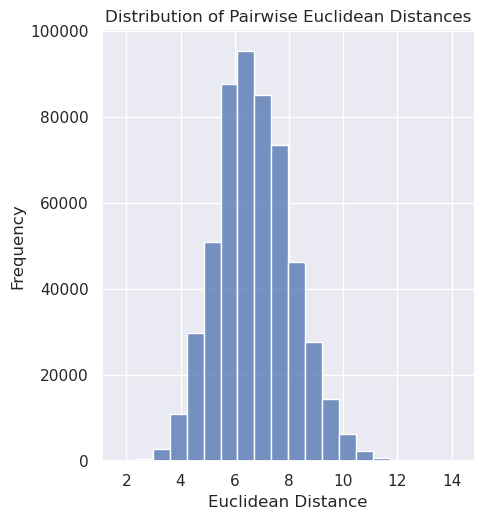

In [15]:
#Problem 5b

# YOUR CODE HERE
sns.displot(distances, bins=20, kde=False)
plt.title("Distribution of Pairwise Euclidean Distances")
plt.xlabel("Euclidean Distance")
plt.ylabel("Frequency")

# DO NOT CHANGE CODE BELOW
plt.show()

<font color = #d14d0f>**QUESTION 6a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Adapt your code from Question 5a so that it determines the row indices of the individuals with the shortest Euclidean distance. The row indices of the individuals should be saved in `identity_1` and `identity_2`, and the distance between them should be saved in `shortest_dist`.  

> **Note:** It may take around a minute for the cell to run. In our testing of the lab in 2025, we find that this cell, even when properly coded, may sometimes crash the Kernel. If this happens, please restart and re-run your cells.


In [16]:
#Question 6a

shortest_dist = np.inf #Initializes the shortest_distance as infinity

# YOUR CODE HERE
identity_1 = -1
identity_2 = -1

num_individuals = len(CODIS_profiles)

for i in range(num_individuals):
    for j in range(i + 1, num_individuals):
        # Calculate distance between individuals i and j
        distance = euclideanDist(CODIS_profiles.iloc[i], CODIS_profiles.iloc[j])
        
        # If this distance is smaller than the current record, update the variables
        if distance < shortest_dist:
            shortest_dist = distance
            identity_1 = i
            identity_2 = j

# DO NOT CHANGE CODE BELOW
print(f"""Individuals {identity_1} and {identity_2} have the shortest Euclidean distance of {shortest_dist:.3} units.""")

Individuals 3 and 730 have the shortest Euclidean distance of 1.73 units.


<font color = #d14d0f>**QUESTION 6b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create the DataFrame `id_comparison` to allow you to manually compare the STR counts of the two individuals determined in Question 6a. The DataFrame indices should be the STR loci, and it should have two columns: `"Person 1"` and `"Person 2"`, which include the STR counts for the individuals. The `"Person 1"` column should contain data from the person with the lower index number.

In [17]:
#Question 6b

# YOUR CODE HERE
id_comparison = pd.DataFrame({
    "Person 1": CODIS_profiles.iloc[identity_1], 
    "Person 2": CODIS_profiles.iloc[identity_2]
})

# DO NOT CHANGE CODE BELOW
id_comparison

,Person 1,Person 2
TPOX,8.0,8.0
D3S1358,15.0,15.0
FGA,21.0,21.0
D5S818,11.0,11.0
CSF1PO,10.0,10.0
D7S820,11.0,11.0
D8S1179,12.0,12.0
TH01,6.0,6.0
vWA,17.0,18.0
D13S317,11.0,11.0


## Diploidy

So far, we only looked at the STR lenght of an allele on one chromosome the shorter alleles for our probability calculations. The original `raw_profiles` DataFrame contains STR alleles for the both chromosomes. The individual's STR count at the same STR locus on their second chromosome is in columns that end with ".1". In this section, we are going to also be considering diploid profiles.  

<font color = #d14d0f>**QUESTION 7a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>


#### Creating a Diploid STR Profile DataFrame

From the original `raw_profiles` DataFrame, you need to create a DataFrame `diploid_profiles` that contains the STR profiles of both chromosomes for each of the original 13 CODIS core loci. 

The `diploid_profiles` DataFrame should have **26 columns**, as each of the original **13 loci** (stored in `CODIS_13_loci`) has two associated values (one for each chromosome). 

##### Step 1: Generate the List of 26 Column Names

First, create a list `CODIS_13_loci_diploid_iterated` that contains the required **26 column names**. This can be done by iterating through `CODIS_13_loci` and appending an additional column name with a `".1"` suffix for each locus.


In [18]:
# Question 7a

CODIS_13_loci_diploid_iterated = []

# YOUR CODE HERE
# Iterate through each locus in CODIS_13_loci to generate the list of 26 column names
for locus in CODIS_13_loci:
    second_chr_loci = locus + ".1"
    CODIS_13_loci_diploid_iterated.append(locus)           # First chromosome label
    CODIS_13_loci_diploid_iterated.append(second_chr_loci)  # Second chromosome label

# DO NOT CHANGE CODE BELOW
print(CODIS_13_loci_diploid_iterated)

['TPOX', 'TPOX.1', 'D3S1358', 'D3S1358.1', 'FGA', 'FGA.1', 'D5S818', 'D5S818.1', 'CSF1PO', 'CSF1PO.1', 'D7S820', 'D7S820.1', 'D8S1179', 'D8S1179.1', 'TH01', 'TH01.1', 'vWA', 'vWA.1', 'D13S317', 'D13S317.1', 'D16S539', 'D16S539.1', 'D18S51', 'D18S51.1', 'D21S11', 'D21S11.1']


<font color = #d14d0f>**QUESTION 7b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>


##### Step 2: Creating the `diploid_profiles` DataFrame

Now, create the DataFrame **`diploid_profiles`** with the needed 26 columns from **`raw_profiles`**, making use of the list **`CODIS_13_loci_diploid_iterated`**.



In [19]:
# Question 7b

# YOUR CODE HERE
# Assign the new columns as part of the Data frame
diploid_profiles = raw_profiles[CODIS_13_loci_diploid_iterated]

# DO NOT CHANGE CODE BELOW
diploid_profiles.head()  

,TPOX,TPOX.1,D3S1358,D3S1358.1,FGA,FGA.1,D5S818,D5S818.1,CSF1PO,CSF1PO.1,...,vWA,vWA.1,D13S317,D13S317.1,D16S539,D16S539.1,D18S51,D18S51.1,D21S11,D21S11.1
0,8,8,14.0,17,24.0,24.0,10,11,11,13,...,17,17,13,13,8,12,13.0,15.0,28.0,30.0
1,8,12,16.0,18,25.0,26.0,11,12,10,12,...,14,19,10,11,10,10,16.0,18.0,30.0,33.2
2,8,11,14.0,17,23.0,25.0,11,12,11,15,...,16,17,11,12,12,12,17.0,17.0,30.2,32.2
3,8,8,15.0,18,21.0,21.0,11,12,10,12,...,17,18,11,11,12,13,15.0,17.0,30.0,31.0
4,9,11,15.0,16,19.0,21.0,9,12,10,12,...,16,18,11,11,11,12,14.0,19.0,31.2,32.2


<font color = #d14d0f>**QUESTION 8**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create an overlaid bar chart that shows the STR count distribution of both TPOX and TPOX.1. Make sure to set an appropriate binwidth, title, legend, and axes labels.

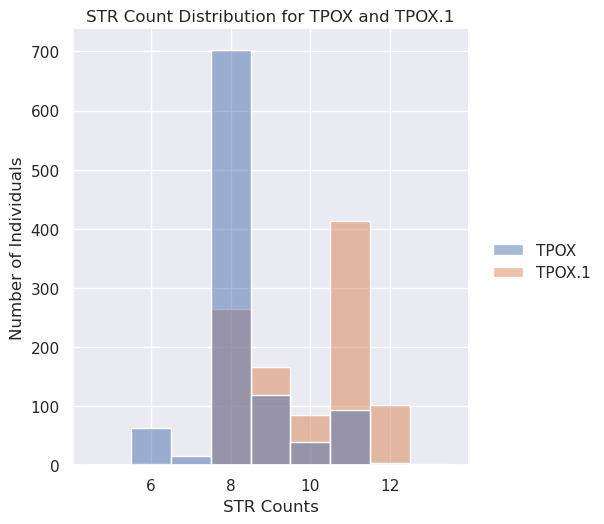

In [20]:
# Question 8

# YOUR CODE HERE
sns.displot(diploid_profiles[["TPOX", "TPOX.1"]], discrete=True, common_norm=False)

# Add titles and labels for clarity
plt.title("STR Count Distribution for TPOX and TPOX.1")
plt.xlabel("STR Counts")
plt.ylabel("Number of Individuals")

# DO NOT CHANGE CODE BELOW
plt.show()

<font color = #d14d0f>**QUESTION 9**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a Series `tpox_diploid_counts`, which shows the distribution frequency of each combination of alleles for TPOX. It should have two index columns `"TPOX"` and `"TPOX.1"`, containing the alleles, and its values should represent the number of individuals in `diploid_profiles` with that combination of alleles.

>**Hint**: See the example code for Question 3. There, we used a Series method. There is an equivalent method for DataFrames that will count combinations of columns. How might you ensure that you only use the subset of columns you care about?

>**Note**: You might notice that the output Series shows what appear as blank spaces for "TPOX" in the first column. These are just merged cells that indicate the block of empty rows share the same value. This Series has what is called a [MultiIndex](https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html#hierarchical-indexing-multiindex)

In [21]:
# Question 9

# YOUR CODE HERE
tpox_diploid_counts = diploid_profiles[["TPOX", "TPOX.1"]].value_counts()

# DO NOT CHANGE CODE BELOW
tpox_diploid_counts.head(10)

TPOX  TPOX.1
8     11        241
      8         233
      9         127
9     11         65
11    11         58
8     10         57
      12         44
11    12         36
10    11         31
9     9          22
dtype: int64

<font color = #d14d0f>**QUESTION 10a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a DataFrame `STR_combinations`, which has three columns `"STR locus"`, `"Most Common Allele Combination"` and `"Probability"`. For each of the 13 loci, determine the most commonly observed pair of alleles and the probability (as a proportion) that a random individual would have that pair of alleles. The most common allele combination of a locus should be formatted as "(allele_1, allele_2)" as a string. The probability should be rounded to 2 decimal places.

>**Hints**:
>
> * You may want to consider how you can apply the approach from Question 9.
> * `df.index.values` will extract the indices of a DataFrame as an array (and the same works for Series). If there are multiple layers of indices, they will be output as an array of tuples.
> * You do not have to follow the skeleton code provided.

In [22]:
# Question 10a

# YOUR CODE HERE
locus_tuples = []

for locus in CODIS_13_loci:
    # Get the counts for all allele combinations at this locus
    diploid_counts = diploid_profiles[[locus, locus + ".1"]].value_counts()
    
    # Identify the most common combination (the first index since value_counts sorts descending)
    # .index.values returns an array of tuples for MultiIndex
    most_common_allele_combination = str(diploid_counts.index.values[0])
    
    # Get the frequency count and calculate the proportion
    most_common_count = diploid_counts.iloc[0]
    most_common_proportion = round(most_common_count / len(diploid_profiles), 2)
    
    # Append the results as a tuple for DataFrame creation
    locus_tuples.append((locus, most_common_allele_combination, most_common_proportion))
# DO NOT CHANGE CODE BELOW
STR_combinations = pd.DataFrame(
    locus_tuples, columns=["STR locus", "Most Common Allele Combination", "Probability"]
)
STR_combinations

,STR locus,Most Common Allele Combination,Probability
0,TPOX,"(8, 11)",0.23
1,D3S1358,"(15.0, 16)",0.17
2,FGA,"(21.0, 22.0)",0.07
3,D5S818,"(11, 12)",0.23
4,CSF1PO,"(11, 12)",0.18
5,D7S820,"(10.0, 11)",0.15
6,D8S1179,"(13, 14)",0.12
7,TH01,"(6.0, 7.0)",0.12
8,vWA,"(16, 17)",0.12
9,D13S317,"(11, 12)",0.18


<font color = #d14d0f>**QUESTION 10b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Calculate the probability that a random individual has the most common allele pair combination for all of the 13 STR loci and assign your result to `probability_most_common_combination`.

In [24]:
# Question 10b

# YOUR CODE HERE
probability_most_common_combination = 1.0

# Iterate through the probabilities calculated in the STR_combinations DataFrame
for prob in STR_combinations["Probability"]:
    # Multiply the cumulative probability by the probability of each locus
    probability_most_common_combination *= prob

# DO NOT CHANGE CODE BELOW
print(f"The probability that a random individual has the most common allele pair combination for each of the 13 STR loci is {probability_most_common_combination:.3e}.")

The probability that a random individual has the most common allele pair combination for each of the 13 STR loci is 3.569e-12.


<font color = #d14d0f>**QUESTION 10c**:</font> <font color = #d14d0f>**NO AI**</font>

How does your answer in 10a relate to the world population and why does this matter?

**Answer 10c**: It shows just how unlikely an individual genetic make up is, how unique it is. It's why, statistically, no two people (bar identitical twins at birth) have identical genetic makeups.


---

### Congratulations! You have finished the notebook! ##

---